# Movilidad Urbana Sustentable

## Analisis de la red Ecobici en la Ciudad Autonoma de Buenos Aires

###Objetivo e Hipotesis

El objetivo de este proyecto es analizar el uso de las bicicletas del sistema Ecobici mediante los datos de viajes provistos por el Gobierno de la Ciudad de Buenos Aires, con el fin de identificar patrones de uso, prever la demanda futura y proponer recomendaciones para redimensionar la red de estaciones de manera óptima durante el año 2024.


####Hipótesis Propuesta

La red de estaciones de Ecobici no está distribuida de manera óptima para cubrir la
demanda real de los usuarios, especialmente durante los horarios pico y en ciertas zonas
de alto tránsito.


## Carga de datos

### Descripción de los datasets utilizados

Para el desarrollo del presente proyecto se trabajará con dos datasets públicos provistos por el Gobierno de la Ciudad Autónoma de Buenos Aires a través del portal de datos abiertos.

- **Recorridos Ecobici 2024**: contiene los registros de viajes realizados durante el año 2024 en el sistema de bicicletas públicas Ecobici. Este dataset servirá como base principal para el análisis y entendimiento del uso del servicio por parte de los usuarios.

- **Usuarios Ecobici**: incluye información anonimizada de los usuarios registrados en el sistema. Su análisis complementa el estudio de los recorridos, permitiendo comprender mejor el perfil de quienes utilizan las Ecobici.

Ambos conjuntos de datos serán utilizados para explorar patrones de uso, comportamiento de los usuarios y generar visualizaciones que permitan obtener conclusiones relevantes para futuras mejoras del sistema.

Descripcion del data set de recorridos:

| Nombre                    | Tipo      | Descripción                                              |
|---------------------------|-----------|----------------------------------------------------------|
| id_recorrido              | integer   | Identificador único del recorrido                        |
| duracion_recorrido        | integer   | Duración del recorrido en segundos                       |
| fecha_origen_recorrido    | date      | Fecha y hora de inicio del recorrido                     |
| id_estacion_origen        | integer   | Identificador único de la estación de origen             |
| nombre_estacion_origen    | string    | Nombre de la estación de origen                          |
| direccion_estacion_origen | string    | Dirección de la estación de origen                       |
| long_estacion_origen      | string    | Longitud geográfica de la estación de origen             |
| lat_estacion_origen       | string    | Latitud geográfica de la estación de origen              |
| fecha_destino_recorrido   | date-time | Fecha y hora de finalización del recorrido               |
| id_estacion_destino       | integer   | Identificador único de la estación de destino            |
| nombre_estacion_destino   | string    | Nombre de la estación de destino                         |
| direccion_estacion_destino| string    | Dirección de la estación de destino                      |
| long_estacion_destino     | number    | Longitud geográfica de la estación de destino            |
| lat_estacion_destino      | string    | Latitud geográfica de la estación de destino             |
| id_usuario                | string    | Identificador único del usuario                          |
| modelo_bicicleta          | string    | Modelo de la bicicleta utilizada en el recorrido         |
| genero                    | string    | Género del usuario (MALE, FEMALE, OTHER)                 |

Descripcion data set usuarios

| Nombre                          | Tipo    | Descripción                                      |
|---------------------------------|---------|--------------------------------------------------|
| ID_usuario                      | integer | Identificador único del usuario                  |
| genero_usuario                  | string  | Género del usuario                               |
| edad_usuario                    | string  | Edad del usuario en años                         |
| fecha_alta                      | date    | Fecha en la que el usuario se registró           |
| hora_alta                       | string  | Hora exacta en la que el usuario se registró     |
| Customer.Has.Dni..Yes...No.     | string  | Indica si el usuario tiene DNI registrado        |

Importación de librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import requests
from io import BytesIO
import zipfile
import io

In [2]:
# URL directa del archivo
url = "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/transporte-y-obras-publicas/bicicletas-publicas/usuarios_ecobici_2024.xlsx"

# Descargar y abrir el Excel
response = requests.get(url)
df_usuarios = pd.read_excel(BytesIO(response.content))
df_usuarios.head()

,ID_usuario,genero_usuario,edad_usuario,fecha_alta,hora_alta,Customer.Has.Dni..Yes...No.
0,1224742,FEMALE,24.0,2024-10-08,12:34:05,No
1,1224990,MALE,18.0,2024-10-08,18:58:27,No
2,1225021,MALE,30.0,2024-10-08,19:55:22,No
3,1224773,OTHER,23.0,2024-10-08,13:25:01,No
4,1225009,MALE,21.0,2024-10-08,19:24:09,No


In [3]:
# URL directa del archivo ZIP
url = "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/transporte-y-obras-publicas/bicicletas-publicas/recorridos-realizados-2024.zip"

# Descargar el archivo ZIP
response = requests.get(url)

# Abrir el archivo ZIP desde memoria
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    # Mostrar los nombres de los archivos dentro del ZIP
    print("Archivos contenidos:", z.namelist())


    filename = [f for f in z.namelist() if f.endswith('.csv')][0]

    # Leer el archivo .xlsx directamente desde el ZIP
    with z.open(filename) as f:
        df_recorridos = pd.read_csv(f)

df_recorridos.head()

Archivos contenidos: ['badata_ecobici_recorridos_realizados_2024.csv']


,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
0,20428222,568,2024-01-23 18:36:00,513,308 - SAN MARTIN II,Av. San Martín 5129,-58.490739,-34.597130,2024-01-23 18:45:28,498,055 - HABANA,Gral. José Gervasio Artigas 4298 (y Habana),-58.494959,-34.586598,992557.0,FIT,MALE
1,20431744,1355,2024-01-23 22:41:20,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,2024-01-23 23:03:55,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,320782.0,FIT,FEMALE
2,20429936,0,2024-01-23 20:06:22,467,328 - SARMIENTO II,Sarmiento 2037,-58.395893,-34.605514,2024-01-23 20:06:22,6,006 - Parque Lezama,"Avenida Martin Garcia, 295",-58.369758,-34.628526,828678.0,FIT,FEMALE
3,20429976,0,2024-01-23 20:08:17,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,2024-01-23 20:08:17,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,320782.0,ICONIC,FEMALE
4,20424802,680,2024-01-23 15:18:39,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-01-23 15:29:59,150,150 - RODRIGO BUENO,Av. España 2200,-58.355465,-34.618755,861425.0,FIT,FEMALE


In [4]:
#Observamos las columnas de ambos datasets
print(f"Columnas Usuarios \n _______________________")
print(df_usuarios.columns)

print(f"\n\n")

print(f"Columnas Recorridos \n _______________________")
print(df_recorridos.columns)

Columnas Usuarios 
 _______________________
Index(['ID_usuario', 'genero_usuario', 'edad_usuario', 'fecha_alta',
       'hora_alta', 'Customer.Has.Dni..Yes...No.'],
      dtype='object')



Columnas Recorridos 
 _______________________
Index(['id_recorrido', 'duracion_recorrido', 'fecha_origen_recorrido',
       'id_estacion_origen', 'nombre_estacion_origen',
       'direccion_estacion_origen', 'long_estacion_origen',
       'lat_estacion_origen', 'fecha_destino_recorrido', 'id_estacion_destino',
       'nombre_estacion_destino', 'direccion_estacion_destino',
       'long_estacion_destino', 'lat_estacion_destino', 'id_usuario',
       'modelo_bicicleta', 'genero'],
      dtype='object')


In [5]:
#Observamos los tipos de datos de los usuarios
df_usuarios.dtypes

,0
ID_usuario,int64
genero_usuario,object
edad_usuario,float64
fecha_alta,datetime64[ns]
hora_alta,object
Customer.Has.Dni..Yes...No.,object


In [6]:
#Observamos los tipos de datos de los recorridos
df_recorridos.dtypes

,0
id_recorrido,int64
duracion_recorrido,int64
fecha_origen_recorrido,object
id_estacion_origen,int64
nombre_estacion_origen,object
direccion_estacion_origen,object
long_estacion_origen,float64
lat_estacion_origen,float64
fecha_destino_recorrido,object
id_estacion_destino,int64


In [7]:
#Observamos la información del usuarios usando .info()
df_usuarios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141539 entries, 0 to 141538
Data columns (total 6 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   ID_usuario                   141539 non-null  int64         
 1   genero_usuario               141539 non-null  object        
 2   edad_usuario                 141539 non-null  float64       
 3   fecha_alta                   141539 non-null  datetime64[ns]
 4   hora_alta                    141539 non-null  object        
 5   Customer.Has.Dni..Yes...No.  141539 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 6.5+ MB


In [8]:
#Observamos la información del usuarios usando .info()
df_recorridos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3559284 entries, 0 to 3559283
Data columns (total 17 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   id_recorrido                int64  
 1   duracion_recorrido          int64  
 2   fecha_origen_recorrido      object 
 3   id_estacion_origen          int64  
 4   nombre_estacion_origen      object 
 5   direccion_estacion_origen   object 
 6   long_estacion_origen        float64
 7   lat_estacion_origen         float64
 8   fecha_destino_recorrido     object 
 9   id_estacion_destino         int64  
 10  nombre_estacion_destino     object 
 11  direccion_estacion_destino  object 
 12  long_estacion_destino       float64
 13  lat_estacion_destino        float64
 14  id_usuario                  float64
 15  modelo_bicicleta            object 
 16  genero                      object 
dtypes: float64(5), int64(4), object(8)
memory usage: 461.6+ MB


In [9]:
#Obsevamos la cantidad de nulos de los usuarios

df_usuarios.isnull().sum()

,0
ID_usuario,0
genero_usuario,0
edad_usuario,0
fecha_alta,0
hora_alta,0
Customer.Has.Dni..Yes...No.,0


In [10]:
df_recorridos.isnull().sum()

,0
id_recorrido,0
duracion_recorrido,0
fecha_origen_recorrido,0
id_estacion_origen,0
nombre_estacion_origen,0
direccion_estacion_origen,0
long_estacion_origen,0
lat_estacion_origen,0
fecha_destino_recorrido,3379
id_estacion_destino,0


In [11]:
#Observamos si hay registros duplicados en los registros

print(f"Datos suplicados en la tabla usuarios: ",df_usuarios.duplicated().sum())
print(f"Datos suplicados en la tabla recorridos: ",df_recorridos.duplicated().sum())

Datos suplicados en la tabla usuarios:  0
Datos suplicados en la tabla recorridos:  1


In [12]:
#Hacemos una descripción de ambas tablas
df_usuarios['edad_usuario'].describe().T

,edad_usuario
count,141539.000000
mean,31.110570
std,14.979091
min,1.013000
25%,22.000000
50%,28.000000
75%,37.000000
max,961.000000


In [13]:
df_usuarios.describe(include='O').T

,count,unique,top,freq
genero_usuario,141539,3,MALE,64071
hora_alta,141539,57308,13:54:11,14
Customer.Has.Dni..Yes...No.,141539,2,Yes,117990


In [14]:
df_recorridos['duracion_recorrido'].describe().T

,duracion_recorrido
count,3.559284e+06
mean,1.274827e+03
std,9.584216e+03
min,0.000000e+00
25%,4.930000e+02
50%,8.810000e+02
75%,1.474000e+03
max,2.571165e+06


In [15]:
df_recorridos.describe(include='O').T

,count,unique,top,freq
fecha_origen_recorrido,3559284,3227772,2024-01-24 19:37:35,13
nombre_estacion_origen,3559284,395,147 - Constitución,38237
direccion_estacion_origen,3559284,393,Avenida Juan de Garay 1050,38237
fecha_destino_recorrido,3555905,3220154,2024-06-13 10:24:25,22
nombre_estacion_destino,3559284,398,147 - Constitución,38281
direccion_estacion_destino,3559284,395,Avenida Juan de Garay 1050,38281
modelo_bicicleta,3559284,2,FIT,2582443
genero,3547338,3,MALE,2147721


### Procesamiento y limpieza

In [16]:
#Evaluamos la cantidad de registros duplicados
df_recorridos.duplicated().sum()

np.int64(1)

In [17]:
df_recorridos[df_recorridos.duplicated()]

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
434351,22425357,1119,2024-07-23 12:30:30,104,104 - Federico Lacroze,Av. Guzman 1100 & Av. Corrientes,-58.455212,-34.587617,2024-07-23 12:49:09,402,-- CDO Chacarita -- (Temporal),3209 Av. Francisco Beiro,-58.498542,-34.597612,1039158.0,FIT,MALE


Observamos el registro dupliado y procederemos a eliminareliminarlo de la base.

In [18]:
df_recorridos[df_recorridos.id_recorrido == 22425357]

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
434350,22425357,1119,2024-07-23 12:30:30,104,104 - Federico Lacroze,Av. Guzman 1100 & Av. Corrientes,-58.455212,-34.587617,2024-07-23 12:49:09,402,-- CDO Chacarita -- (Temporal),3209 Av. Francisco Beiro,-58.498542,-34.597612,1039158.0,FIT,MALE
434351,22425357,1119,2024-07-23 12:30:30,104,104 - Federico Lacroze,Av. Guzman 1100 & Av. Corrientes,-58.455212,-34.587617,2024-07-23 12:49:09,402,-- CDO Chacarita -- (Temporal),3209 Av. Francisco Beiro,-58.498542,-34.597612,1039158.0,FIT,MALE


In [19]:
df_recorridos.drop_duplicates()

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
0,20428222,568,2024-01-23 18:36:00,513,308 - SAN MARTIN II,Av. San Martín 5129,-58.490739,-34.597130,2024-01-23 18:45:28,498,055 - HABANA,Gral. José Gervasio Artigas 4298 (y Habana),-58.494959,-34.586598,992557.0,FIT,MALE
1,20431744,1355,2024-01-23 22:41:20,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,2024-01-23 23:03:55,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,320782.0,FIT,FEMALE
2,20429936,0,2024-01-23 20:06:22,467,328 - SARMIENTO II,Sarmiento 2037,-58.395893,-34.605514,2024-01-23 20:06:22,6,006 - Parque Lezama,"Avenida Martin Garcia, 295",-58.369758,-34.628526,828678.0,FIT,FEMALE
3,20429976,0,2024-01-23 20:08:17,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,2024-01-23 20:08:17,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,320782.0,ICONIC,FEMALE
4,20424802,680,2024-01-23 15:18:39,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-01-23 15:29:59,150,150 - RODRIGO BUENO,Av. España 2200,-58.355465,-34.618755,861425.0,FIT,FEMALE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3559279,21526830,506,2024-04-25 21:35:33,93,093 - CARLOS CALVO,Sarandi 1010,-58.394464,-34.620798,2024-04-25 21:43:59,175,147 - Constitución,Avenida Juan de Garay 1050,-58.380707,-34.626851,1124148.0,ICONIC,MALE
3559280,21525192,970,2024-04-25 17:34:30,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-04-25 17:50:40,93,093 - CARLOS CALVO,Sarandi 1010,-58.394464,-34.620798,1124148.0,FIT,MALE
3559281,21525370,1442,2024-04-25 17:45:12,263,270 - PLAZA DEL ANGEL GRIS,Calcena & Avellaneda Av.,-58.457555,-34.622003,2024-04-25 18:09:14,263,270 - PLAZA DEL ANGEL GRIS,Calcena & Avellaneda Av.,-58.457555,-34.622003,870169.0,FIT,MALE
3559282,21526289,520,2024-04-25 19:28:49,222,160 - Godoy Cruz y Libertador,Av. Cerviño 4301,-58.418543,-34.575919,2024-04-25 19:37:29,124,124 - UGARTECHE,Juan María Gutiérrez 2069,-58.412625,-34.581114,222965.0,ICONIC,FEMALE


In [20]:
# A continuación procederemos a transformar las fechas en formato date time

def convertir_a_datetime(df, columnas):
    for columna in columnas:
        df[columna] = pd.to_datetime(df[columna])

convertir_a_datetime(df_recorridos, ['fecha_origen_recorrido', 'fecha_destino_recorrido'])
convertir_a_datetime(df_usuarios, ['fecha_alta'])

In [21]:
#Calculo de la fecha de llegada para los registros nulos y comparar

df_recorridos['fecha_llegada'] = df_recorridos['fecha_origen_recorrido'] + pd.to_timedelta(df_recorridos['duracion_recorrido'], unit='s')


In [22]:
df_veriacion_recorridos = df_recorridos[
    (df_recorridos['fecha_destino_recorrido'].notnull()) &
     (df_recorridos['fecha_llegada'] != df_recorridos['fecha_destino_recorrido'])]

df_veriacion_recorridos['variacion_minutos'] = (
    (df_veriacion_recorridos['fecha_destino_recorrido'] - df_veriacion_recorridos['fecha_llegada']).dt.total_seconds() / 60)

df_veriacion_recorridos

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero,fecha_llegada,variacion_minutos
557750,22399803,369,2024-07-19 14:44:34,208,145 - RAVIGNANI,EMILIO RAVIGNANI 1802,-58.438404,-34.580716,2024-07-19 14:44:34,534,081 - PARQUE DE LAS CIENCIAS,Soler 5300,-58.429979,-34.582963,885444.0,FIT,MALE,2024-07-19 14:50:43,-6.150000
821988,21171111,1304,2024-03-26 15:15:16,166,166 - Cementerio de Recoleta,Vicente López 2100,-58.394148,-34.588347,2024-03-26 15:15:16,54,054 - Acuña de Figueroa,Lavalle 4015,-58.422069,-34.598210,6038.0,FIT,MALE,2024-03-26 15:37:00,-21.733333
1009269,23372132,22,2024-10-09 16:51:50,181,181 - BILLINGHURST Y MANSILLA,"1520 Billinghurst & Mansilla, Lucio Norberto, ...",-58.412007,-34.592665,2024-10-09 16:51:50,181,181 - BILLINGHURST Y MANSILLA,"1520 Billinghurst & Mansilla, Lucio Norberto, ...",-58.412007,-34.592665,1159377.0,FIT,MALE,2024-10-09 16:52:12,-0.366667
1290169,24217120,608,2024-12-09 05:07:19,569,339 - HIPODROMO DE PALERMO,Av. del Libertador 4175,-58.427288,-34.568757,2024-12-09 05:07:19,289,255 - BARRANCAS DE BELGRANO,"Sucre, Antonio Jose De, Mcal. Y Vertiz Virrey Av.",-58.448314,-34.559801,268812.0,FIT,FEMALE,2024-12-09 05:17:27,-10.133333
1360008,21036630,31,2024-03-15 15:44:29,54,054 - Acuña de Figueroa,Lavalle 4015,-58.422069,-34.598210,2024-03-15 15:44:29,54,054 - Acuña de Figueroa,Lavalle 4015,-58.422069,-34.598210,695547.0,ICONIC,OTHER,2024-03-15 15:45:00,-0.516667
2649438,21824598,636,2024-05-24 12:10:45,14,014 - Pacifico,"Santa Fe Av. & Bullrich, Int. Av.",-58.426387,-34.577424,2024-05-24 12:10:45,44,044 - Ecoparque,"Av. Del Libertador, 3260",-58.413883,-34.575515,831849.0,FIT,FEMALE,2024-05-24 12:21:21,-10.600000
2800619,22826237,405,2024-09-01 19:44:02,122,122 - COSTA RICA,COSTA RICA 4060,-58.419816,-34.591561,2024-09-01 19:44:02,161,161 - Humahuaca,3912 Humahuaca,-58.419676,-34.602078,1019678.0,ICONIC,MALE,2024-09-01 19:50:47,-6.750000
3296872,22637725,1470,2024-08-13 16:27:56,22,022 - Arenales,Cerrito & Arenales,-58.382550,-34.593863,2024-08-13 16:27:56,124,124 - UGARTECHE,Juan María Gutiérrez 2069,-58.412625,-34.581114,78821.0,FIT,MALE,2024-08-13 16:52:26,-24.500000


La variación de los 8 registros no es significativa por lo cual decidimos reemplazar la fecha destino recorrido por el calculado asi tambien reemplazando a los registros nulos de fecha_destino_recorrido


In [23]:
df_recorridos['fecha_destino_recorrido'] = df_recorridos['fecha_llegada']
df_recorridos.drop('fecha_llegada', axis=1, inplace=True)

In [24]:
#Observamos la cantidad de generos y proporcion de nulos en genero:

print(f'Cantidad de de nulos : ',(df_recorridos['genero'].isnull().sum()))
print(f'% de nulos : ',(df_recorridos['genero'].isnull().sum()/df_recorridos.shape[0]).astype(float)*100)

Cantidad de de nulos :  11946
% de nulos :  0.33562930072452773


In [25]:
#observamos la distribución de los generos:

df_recorridos['genero'].value_counts(normalize = True)*100

,proportion
genero,
MALE,60.544583
FEMALE,31.958049
OTHER,7.497368


Observando la distribución de variables procederemos a asignar el 0.33% de los nulos a valor other, por ser el menos repetido.

In [26]:
df_recorridos['genero'].fillna('OTHER', inplace=True)

## Analisis Univariado

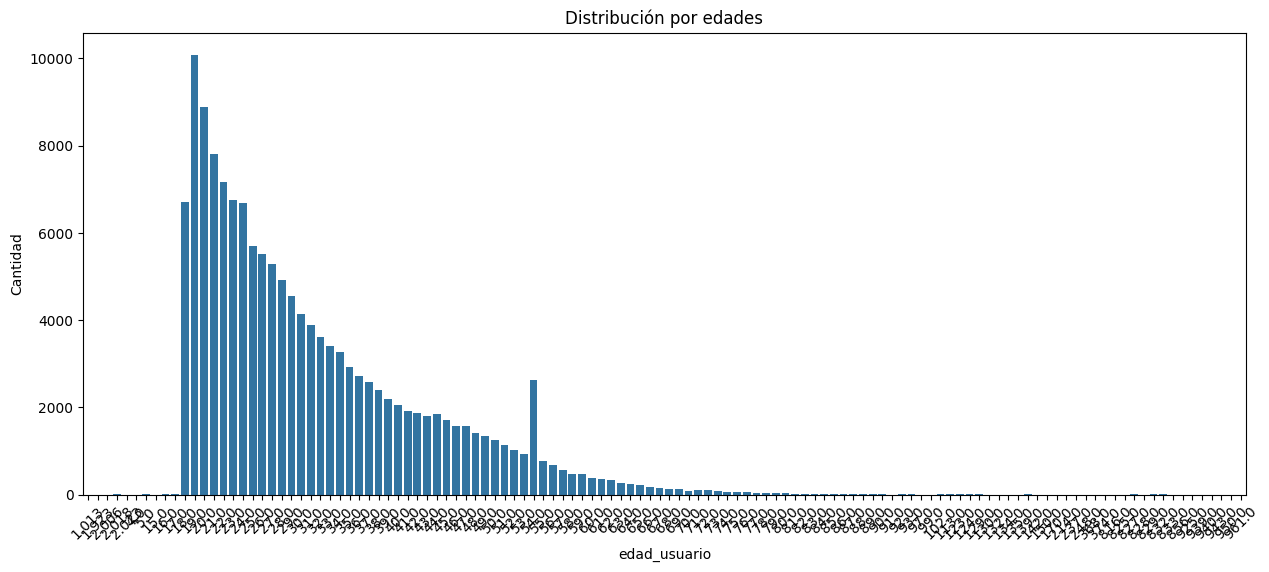

In [30]:
#Distribución de edad

fig, ax = plt.subplots(figsize=(15,6))
edad = pd.DataFrame(df_usuarios.groupby(['edad_usuario'])['ID_usuario'].count())
sns.barplot(x=edad.index, y=edad['ID_usuario'], ax=ax)
plt.ylabel('Cantidad')
plt.title('Distribución por edades')

# Rotar las etiquetas de edad para que se vea mejor
plt.xticks(rotation=45)

plt.show()

Observando la distribución de la variable edad obsevamos algunas inconsistencias, asi que observaremos los registros cuya edad exceden los 100 años y esten debajo de los 15 años


In [36]:
print(f"Cantidad de usuarios con edad mayor a 100 : ",df_usuarios[df_usuarios['edad_usuario'] > 100].shape[0])
print(f"Cantidad de usuarios con edad mayor a 15 : ",df_usuarios[df_usuarios['edad_usuario'] < 15].shape[0])

Cantidad de usuarios con edad mayor a 100 :  41
Cantidad de usuarios con edad mayor a 15 :  10


Siendo que estos registros parecen ser errores los cuales no podemos identificar o estimar la edad ya que no contamos con información sensible como el numero de documento y debido al bajo impacto en el analisis eliminaremos los registros.

In [37]:
df_usuarios = df_usuarios[df_usuarios['edad_usuario'] <= 100]
df_usuarios = df_usuarios[df_usuarios['edad_usuario'] >= 15]
df_usuarios['edad_usuario'].describe()

,edad_usuario
count,141488.000000
mean,30.989504
std,11.645610
min,15.000000
25%,22.000000
50%,28.000000
75%,37.000000
max,99.000000


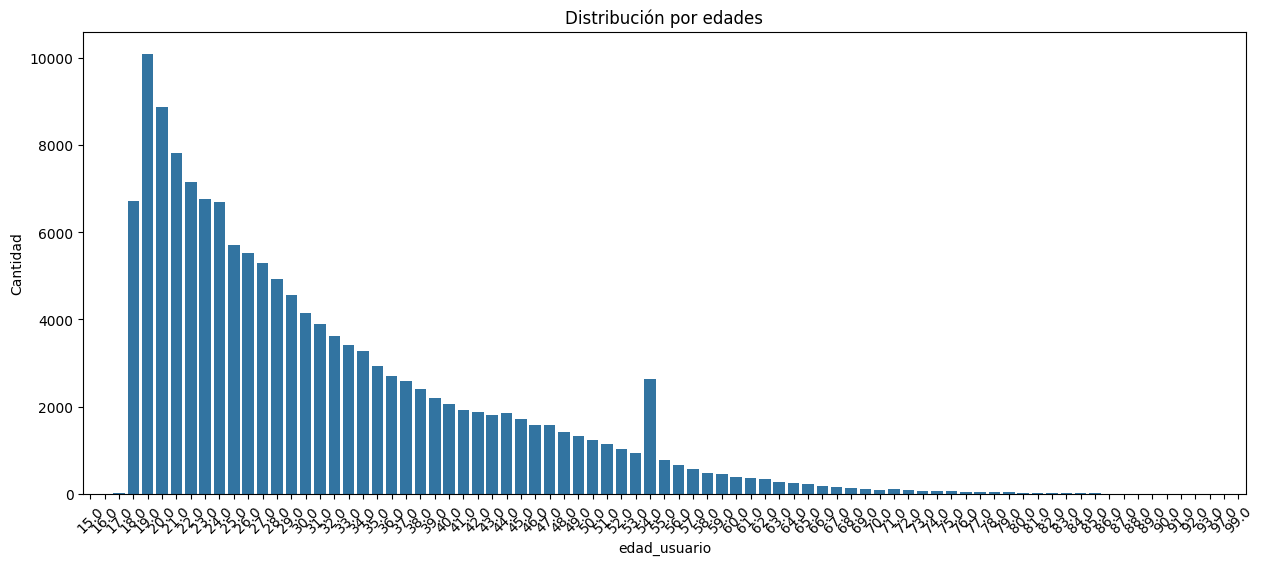

In [48]:
fig, ax = plt.subplots(figsize=(15,6))
edad = pd.DataFrame(df_usuarios.groupby(['edad_usuario'])['ID_usuario'].count())
sns.barplot(x=edad.index, y=edad['ID_usuario'], ax=ax)
plt.ylabel('Cantidad')
plt.title('Distribución por edades')

# Rotar las etiquetas de edad para que se vea mejor
plt.xticks(rotation=45)

plt.show()

Observamos que los usuarios registrados durante 2024 parecen ser en su mayoria jovenes de entre 18 y 24 años

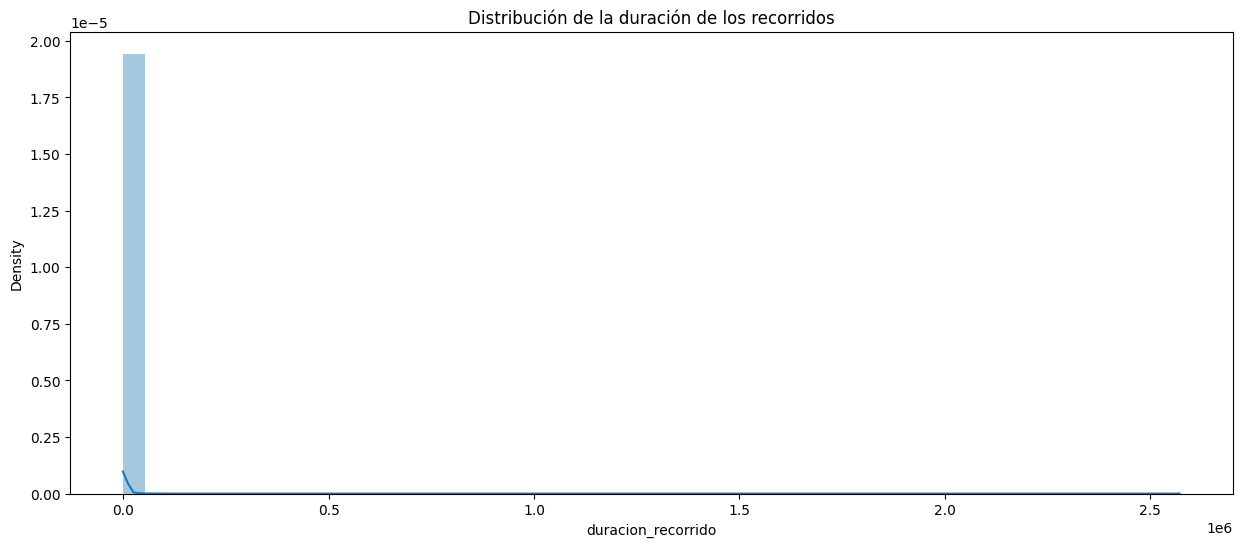

In [39]:
#Observamos la distirbución de la duración de los recorridos

fig, ax = plt.subplots(figsize=(15,6))
sns.distplot(df_recorridos['duracion_recorrido'], ax=ax)
plt.title('Distribución de la duración de los recorridos')
plt.show()

Usaremos el metodo el IQR y Z score para observar la cantidad de outliers y poder tomar decisiones

In [40]:
Q1 = df_recorridos['duracion_recorrido'].quantile(0.25)
Q3 = df_recorridos['duracion_recorrido'].quantile(0.75)
IQR = Q3 - Q1

# Paso 2: Definir los límites inferior y superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Paso 3: Encontrar outliers
outliers_iqr = df_recorridos[
    (df_recorridos['duracion_recorrido'] < limite_inferior) |
    (df_recorridos['duracion_recorrido'] > limite_superior)
]

# Mostrar cantidad de outliers
print(f'Cantidad de outliers detectados con IQR: {outliers_iqr.shape[0]}')

Cantidad de outliers detectados con IQR: 197787


In [44]:
from scipy import stats

# calculo del zscore
z_scores = stats.zscore(df_recorridos['duracion_recorrido'])

#en este caso elegimos 3 desvios estandars
umbral = 3

outliers_zscore = df_recorridos[
    (z_scores > umbral) | (z_scores < -umbral)
]

print(f'Cantidad de outliers detectados con Z-Score: {outliers_zscore.shape[0]}')

Cantidad de outliers detectados con Z-Score: 2420


Siendo que el Z Score es mas util cuando las variables siguen una distribución normal y este no seria el caso, realizaremos una limpieza del dataset usando el metodo del IQR y guardandolo en un nuevo dataframe.

In [45]:
df_recorridos_limpio = df_recorridos[
    (df_recorridos['duracion_recorrido'] >= limite_inferior) &
    (df_recorridos['duracion_recorrido'] <= limite_superior)
]

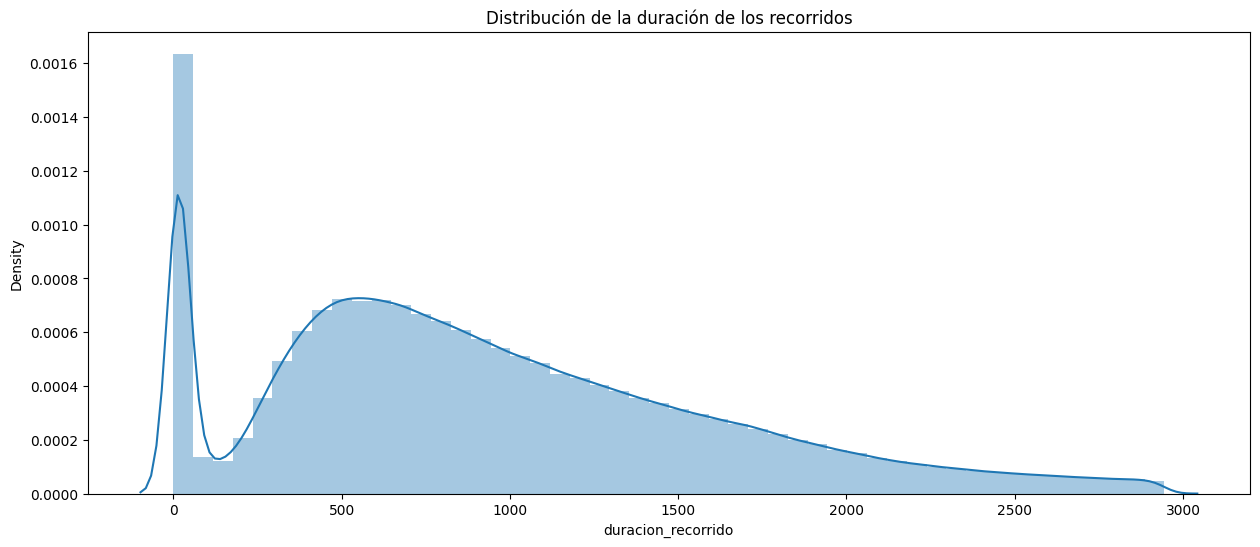

In [47]:

fig, ax = plt.subplots(figsize=(15,6))
sns.distplot(df_recorridos_limpio['duracion_recorrido'], ax=ax)
plt.title('Distribución de la duración de los recorridos')
plt.show()

La distribución de nuestra variable sin sesgos muestra una distribución bimodal donde encontramos muchos registros cercanos al valor 0, lo que probablemente significa que los usuarios sacaron y devolvieron la bici. Por otro lado, observamos una sesgo hacia la izquierda, lo que indica que los usuarios suelen usar las bicis en recorridos mas bien cortos.

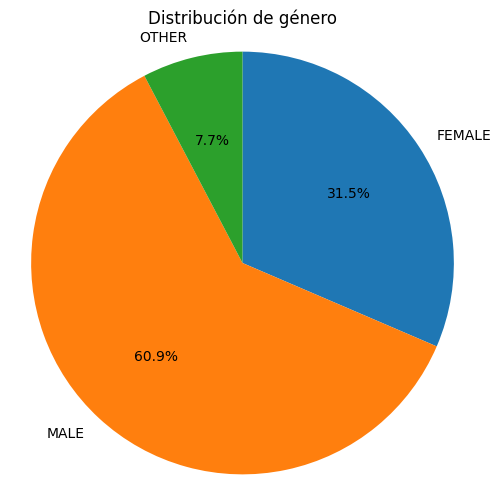

In [52]:
#Observamos la distribución de genero:

data = df_recorridos_limpio.groupby('genero')['id_recorrido'].count()

fig, ax = plt.subplots(figsize=(6,6))
ax.pie(
    data,
    labels=data.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)

ax.set_title('Distribución de género')
ax.axis('equal')
plt.show()

La mayoria de los usuarios de ecobici que realizaron recorridos durante el 2024 fueron hombres

## Analisis Bivariado

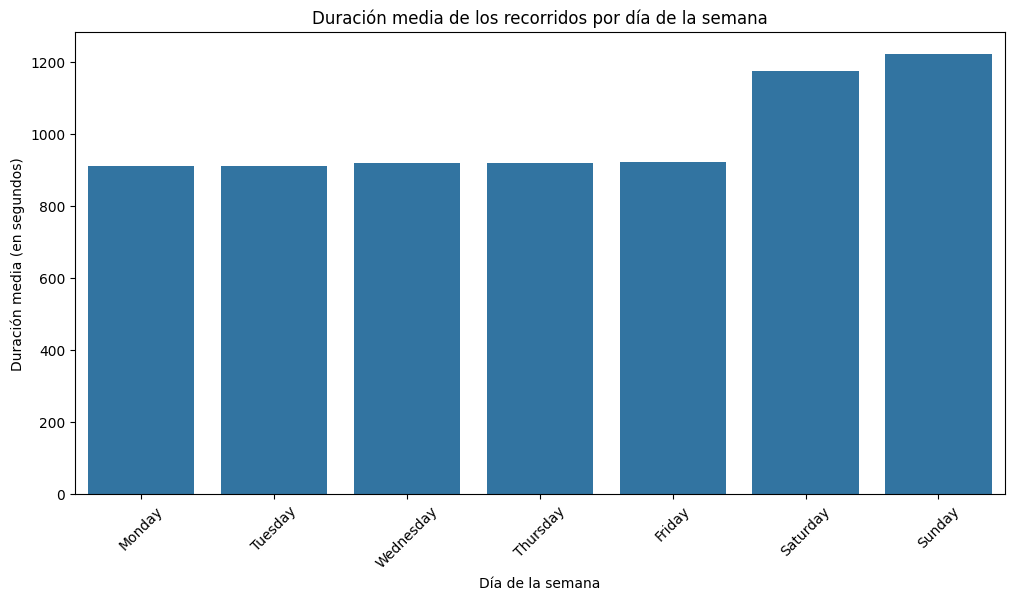

In [56]:
#Observemos la duración media de los recorridos durante los dias de semana

df_recorridos_limpio['dia_semana'] = df_recorridos_limpio['fecha_origen_recorrido'].dt.day_name()

duracion_media = df_recorridos_limpio.groupby('dia_semana')['duracion_recorrido'].mean().reset_index()

orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

duracion_media['dia_semana'] = pd.Categorical(duracion_media['dia_semana'], categories= orden_dias, ordered=True)
duracion_media = duracion_media.sort_values('dia_semana')

fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(
    x='dia_semana',
    y='duracion_recorrido',
    data=duracion_media,
    ax=ax
)

ax.set_title('Duración media de los recorridos por día de la semana')
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Duración media (en segundos)')
plt.xticks(rotation=45)
plt.show()

Observamos que a lo largo del año los dias donde las bicis se usaron en promedio con mayor duración han sido los fines de semana.

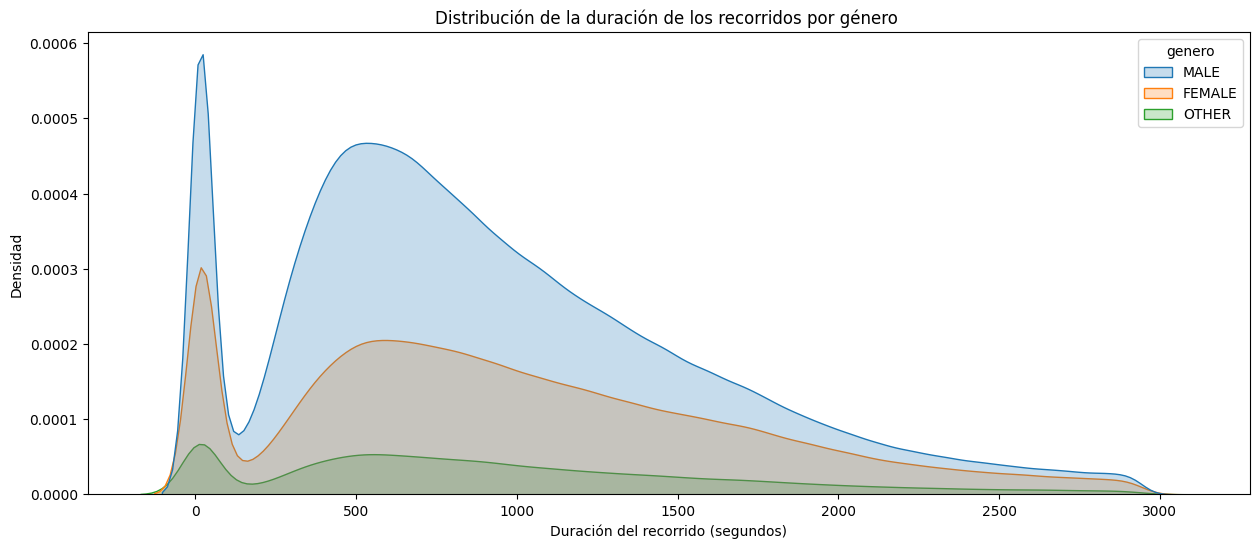

In [59]:
#Observemos la distribución de los recorridos por genero
fig, ax = plt.subplots(figsize=(15,6))
sns.kdeplot(
    data=df_recorridos_limpio,
    x='duracion_recorrido',
    hue='genero',
    ax=ax,
    fill=True
)

plt.title('Distribución de la duración de los recorridos por género ')
plt.xlabel('Duración del recorrido (segundos)')
plt.ylabel('Densidad')
plt.show()

Observamos que la distribución de la dureación de los recorridos para los 3 generos identificados parece ser equitativa.

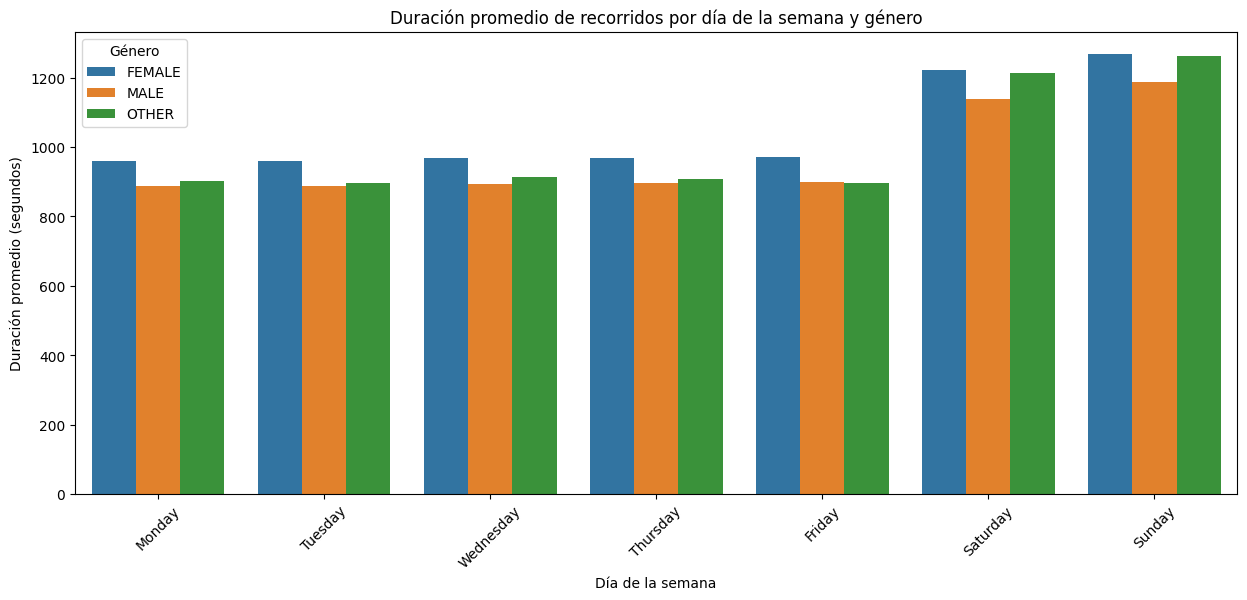

In [61]:
#Observemos la duración de los viajes en la semana por genero

duracion_media_genero = df_recorridos_limpio.groupby(['dia_semana', 'genero'])['duracion_recorrido'].mean().reset_index()

duracion_media_genero['dia_semana'] = pd.Categorical(duracion_media_genero['dia_semana'], categories=orden_dias, ordered=True)

fig, ax = plt.subplots(figsize=(15,6))

sns.barplot(
    data=duracion_media_genero,
    x='dia_semana',
    y='duracion_recorrido',
    hue='genero',
    ax=ax
)

ax.set_title('Duración promedio de recorridos por día de la semana y género')
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Duración promedio (segundos)')
plt.xticks(rotation=45)
plt.legend(title='Género')
plt.show()

Observamos que en promedio, los usuarios de distintos generos usan de forma similar las bicicletas.
